# PyPSA Network Analysis: Germany 24h

This notebook analyzes the results of a PyPSA simulation for the German power grid, focusing on topology, demand, and generation.

**Scenario Details:**
- **Region:** Germany 
- **Time Period:** A single day (2025-05-14)
- **Resolution:** Hourly snapshots (24 snapshots total)
- **Network Clustering:** 470 clusters

---
## 1. Setup and Configuration
This section imports the necessary libraries and loads the solved PyPSA network data.

### 1.1. Import Libraries

In [57]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs

### 1.2. Load Network Data
Load the solved network model from its `.nc` file.

In [58]:
config_name = "germany"
cluster = "470"

# Path to the network file before solving
network_path_unsolved = f"pypsa-eur/resources/{config_name}/networks/base_s_{cluster}_elec.nc"
n_unsolved = pypsa.Network(network_path_unsolved)


# Path to the network file after solving
network_path_solved = f"pypsa-eur/results/{config_name}/networks/base_s_{cluster}_elec_.nc"
n = pypsa.Network(network_path_solved)

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


### Input values for the model (before solving step)

In [59]:
# nominal power 
n.lines.s_nom.to_frame().head()

,s_nom
name,
0,4379.317262
1,491.556019
10,3396.205223
100,3396.205223
101,1698.102612


In [60]:
# actual hourly demand values for the first few loads
n_unsolved.loads_t.p_set.head()

name,DE0 0,DE0 1,DE0 10,DE0 100,DE0 101,DE0 102,DE0 103,DE0 104,DE0 105,DE0 106,...,DE0 90,DE0 91,DE0 92,DE0 93,DE0 94,DE0 95,DE0 96,DE0 97,DE0 98,DE0 99
snapshot,,,,,,,,,,,,,,,,,,,,,
2025-05-14 00:00:00,289.831467,310.849350,111.864609,282.097824,73.966728,5.340652,74.140434,244.746414,50.563736,524.128044,...,202.955887,135.591370,184.350510,55.434921,184.881195,421.603592,106.520699,25.496117,42.774193,143.943298
2025-05-14 01:00:00,289.238136,310.212990,111.635605,281.520325,73.815300,5.329720,73.988655,244.245377,50.460228,523.055069,...,202.540405,135.313789,183.973114,55.321442,184.502716,420.740501,106.302635,25.443924,42.686623,143.648621
2025-05-14 02:00:00,297.225868,318.779968,114.718582,289.294914,75.853821,5.476913,76.031960,250.990562,51.853760,537.499992,...,208.133850,139.050674,189.053795,56.849220,189.598030,432.359863,109.238335,26.146599,43.865479,147.615685
2025-05-14 03:00:00,320.526619,343.770439,123.711845,311.973930,81.800308,5.906265,81.992416,270.666740,55.918785,579.636818,...,224.450317,149.951431,203.874496,61.305862,204.461395,466.254318,117.801979,28.196335,47.304268,159.187881
2025-05-14 04:00:00,365.281494,391.770821,140.985626,355.534592,93.222023,6.730957,93.440948,308.459717,63.726685,660.571030,...,255.790131,170.889023,232.341324,69.865952,233.010170,531.357033,134.250572,32.133362,53.909325,181.415161


---
## 2. Network Topology and Geographical Visualization
This section provides an overview of the network's structure and visualizes it on a map. The plots range from a simple static overview to more detailed interactive versions.

### 2.1. Network Summary
A high-level summary of the components in the network.

In [61]:
n

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 1410
 - Carrier: 21
 - Generator: 2667
 - Line: 666
 - Link: 1898
 - Load: 470
 - Store: 940
 - SubNetwork: 1
Snapshots: 24

### 2.2. Static Network Plot with Load Distribution
The plot below shows the network buses and lines. The size of each bus corresponds to its electrical load at a specific snapshot, and the line colors distinguish between AC and DC lines.

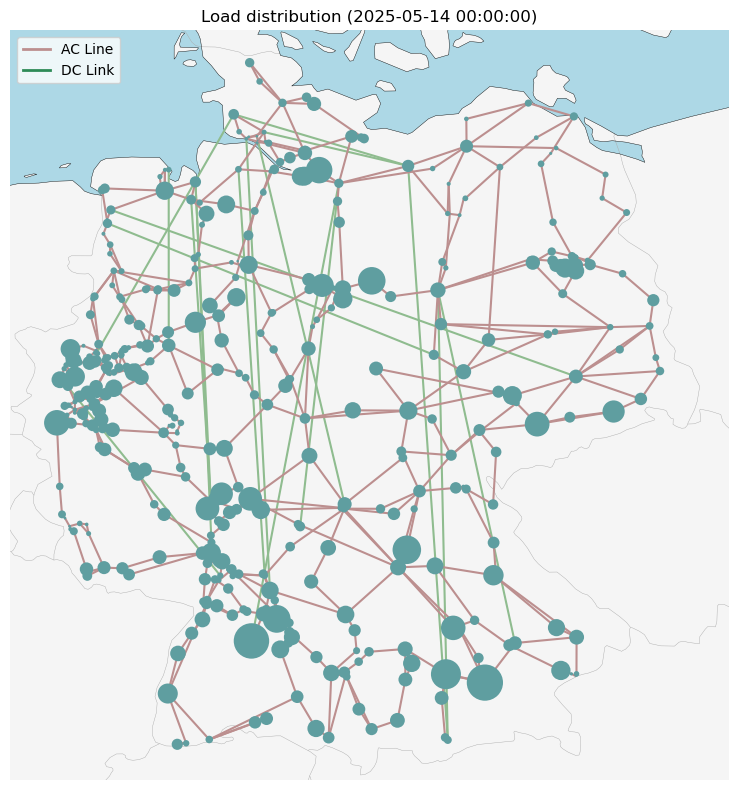

In [62]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.EqualEarth()},
)

snapshot = n.snapshots[0]
load_distribution = n.loads_t.p_set.loc[snapshot].groupby(n.loads.bus).sum()

n.plot(
    bus_sizes=(load_distribution/20000),
    ax=ax,
    geomap=True,
    title=f"Load distribution ({snapshot})",
    geomap_color=True
);

# --- Add custom legend for line types ---
legend_elements = [
    Line2D([0], [0], color='rosybrown', lw=2, label='AC Line'),
    Line2D([0], [0], color='seagreen', lw=2, label='DC Link')
]
ax.legend(handles=legend_elements, loc='upper left')
# -----------------------------------------

plt.tight_layout()
plt.show()

### 2.4. Detailed Map
CURRENTLY NOT WORKING: This plot shows the energy balance at each bus using pie charts. The size of the pie chart represents the total energy, and the slices show the contribution of different carriers (generation, load, storage).

Line loading is the ratio of the power flowing through a line to its nominal capacity. This plot shows the loading for a specific snapshot.

1.  **`loading`**: This variable represents the loading of each transmission line as a ratio. It's calculated as `n.lines_t.p0 / n.lines.s_nom`, which is the actual power flow on the line divided by the line's maximum capacity.

2.  **Direction of Flow**: Power flow (`p0`) in PyPSA has a direction. It can be positive or negative depending on whether power is flowing from `bus0` to `bus1` or vice-versa. Consequently, the `loading` variable can have negative values (e.g., -0.7, meaning 70% of capacity is used, but in the reverse direction).

3.  **`.abs()`**: This is the absolute value function. When you call `.abs()`, it converts all the negative loading values to positive ones. For example, a loading of `-0.7` becomes `0.7`.

Line loading statistics for snapshot 2025-05-14 09:00:00:


count    666.000000
mean       0.007003
std        0.321585
min       -2.196253
25%       -0.160307
50%        0.007877
75%        0.183203
max        1.203252
dtype: float64

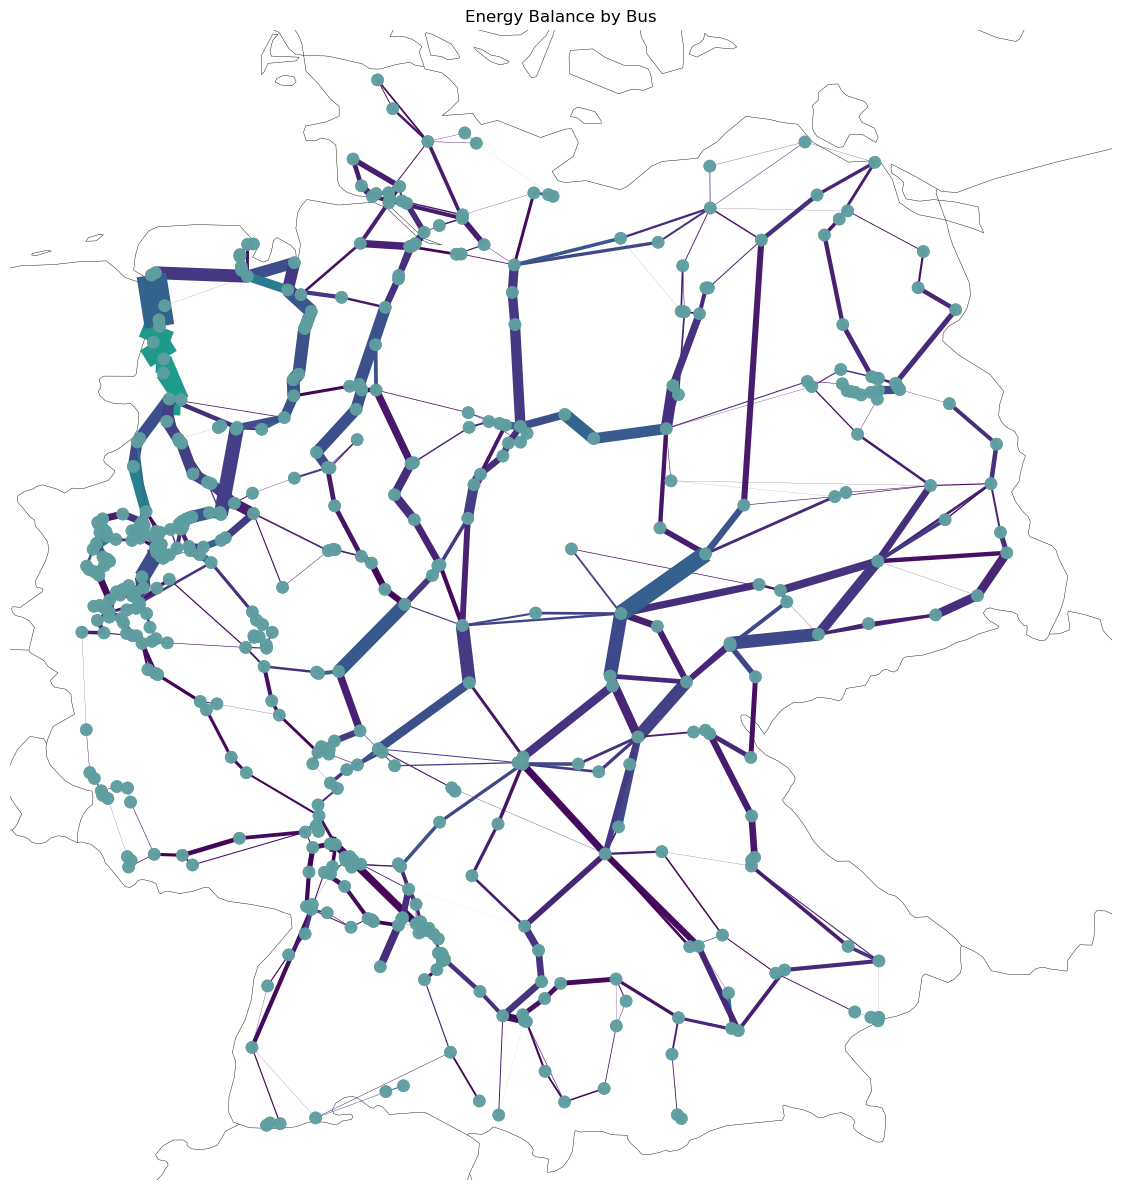

In [63]:
# Calculate energy balance for pie charts
eb = (
    n.statistics.energy_balance(
        groupby=["bus", "carrier"],
        components=["Generator", "Load", "StorageUnit"],
    )
    .groupby(["bus", "carrier"])
    .sum()
)

# Define colors for carriers
colors = {
    "biomass": "green", "coal": "black", "lignite": "brown",
    "offwind-ac": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "orange", "oil": "gray", "ror": "turquoise", "geothermal": "red",
    "Load": "darkred", # Color for load
}
n.carriers.color = n.carriers.index.map(colors)
n.carriers.loc["", "color"] = "darkred"
n.carriers.loc["-", "color"] = "darkred"


# Calculate total flow for line/link widths
line_flow = n.lines_t.p0.sum(axis=0)
link_flow = n.links_t.p0.sum(axis=0)

bus_size_factor = 1e9
branch_width_factor = 4000

# Create a new figure for this plot
fig, ax = plt.subplots(
    1, 1, figsize=(12, 12),
    subplot_kw={"projection": ccrs.EqualEarth()}
)
# Select a snapshot to analyze
now = n.snapshots[9]
loading = n.lines_t.p0.loc[now] / n.lines.s_nom
print(f"Line loading statistics for snapshot {now}:")
display(loading.describe())

n.plot(
    ax=ax,
    geomap=True,
    line_colors=loading.abs(),
    bus_sizes=eb.abs().sum() / bus_size_factor,
    bus_alpha=0.7,
    bus_split_circle=True,
    line_width=line_flow / branch_width_factor,
    link_width=link_flow / branch_width_factor,
    title="Energy Balance by Bus"
)
plt.tight_layout()
plt.show()


plt.show()

---
## 3. Demand (Load) Analysis
This section explores the electricity demand across the network, from high-level summaries to detailed time-series profiles.

### 3.1. Top Buses by Annual Load
A summary of the buses with the highest total electricity consumption over the simulation period.

In [64]:
if not n.loads.empty and hasattr(n.loads_t, "p_set") and not n.loads_t.p_set.empty:
    annual_load_by_bus = n.loads_t.p_set.sum().sort_values(ascending=False)
    print("\nTop buses by annual load [MWh over snapshots]:")
    display(annual_load_by_bus.head(15).to_frame("load_MWh"))


Top buses by annual load [MWh over snapshots]:


,load_MWh
name,
DE0 12,28919.592598
DE0 44,27656.320076
DE0 36,19800.852264
DE0 15,17928.510086
DE0 129,16935.742867
DE0 45,16732.389915
DE0 106,15435.780922
DE0 116,14382.988495
DE0 62,13479.436447


### 3.2. Total Load Over Simulation Period
The total aggregated load for the entire network over all snapshots.

In [65]:
# Total load over the simulation period
loads = n.loads_t.p_set.sum().to_frame("total_load_MWh") #sum over all snapshots
print("Total load summary:")
loads

Total load summary:


,total_load_MWh
name,
DE0 0,8535.652924
DE0 1,9154.637886
DE0 10,3294.457565
DE0 100,8307.893974
DE0 101,2178.349686
...,...
DE0 95,12416.394791
DE0 96,3137.077316
DE0 97,750.870926


### 3.3. Load Profile for Multiple Buses
This plot shows the electricity demand (load) over the 24-hour period for the first five buses in the network.

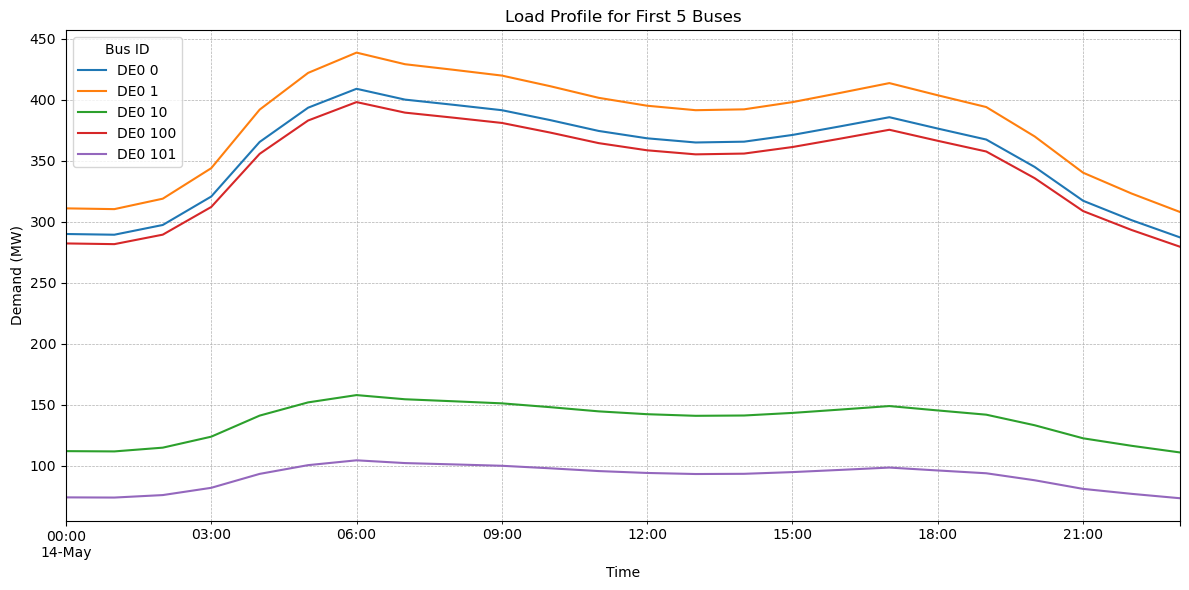

In [66]:
# --- Plot load for multiple buses ---

# Choose buses to inspect (e.g., the first 5)
buses_to_plot = n.buses.index[:5]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

for bus in buses_to_plot:
    # Find all loads connected to this bus
    loads_on_bus = n.loads[n.loads.bus == bus].index
    
    # Get the time-series data for these loads and sum them up
    if not loads_on_bus.empty:
        load_profile = n.loads_t.p_set[loads_on_bus].sum(axis=1)
        load_profile.plot(ax=ax, label=bus)

ax.set_title("Load Profile for First 5 Buses")
ax.set_ylabel("Demand (MW)")
ax.set_xlabel("Time")
ax.legend(title="Bus ID")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

---
## 4. Generation Analysis
This section visualizes the generation side of the network, including installed capacities, dispatch patterns, and curtailment.

### 4.1. Installed Capacity Analysis
An overview of the installed generation capacity, grouped by carrier type and by bus.

In [67]:
if not n.generators.empty:
    cap_by_carrier = n.generators.groupby("carrier")["p_nom"].sum().sort_values(ascending=False)
    print("Installed generator capacity by carrier [MW]:")
    display(cap_by_carrier.head(20).to_frame("p_nom_MW"))

    cap_by_bus = n.generators.groupby("bus")["p_nom"].sum().sort_values(ascending=False)
    print("\nTop buses by installed generation capacity [MW]:")
    display(cap_by_bus.head(15).to_frame("p_nom_MW"))

Installed generator capacity by carrier [MW]:


,p_nom_MW
carrier,
onwind,73332.065900
solar,48771.254020
CCGT,30783.128330
coal,20351.945000
lignite,19457.035000
offwind-ac,11163.743000
biomass,8020.001833
OCGT,6112.743723
oil,5684.345986



Top buses by installed generation capacity [MW]:


,p_nom_MW
bus,
DE0 358,6615.661395
DE0 140,4622.186951
DE0 310,4616.836090
DE0 399,4281.689030
DE0 116,3952.658212
DE0 32,3930.192727
DE0 55,3235.673001
DE0 312,3185.559024
DE0 430,3103.332880


### 4.2. Average Generator Availability per Carrier
The following plots show the average `p_max_pu` (per unit maximum availability) for all generators of a specific carrier type. This is particularly relevant for renewable sources like wind and solar.

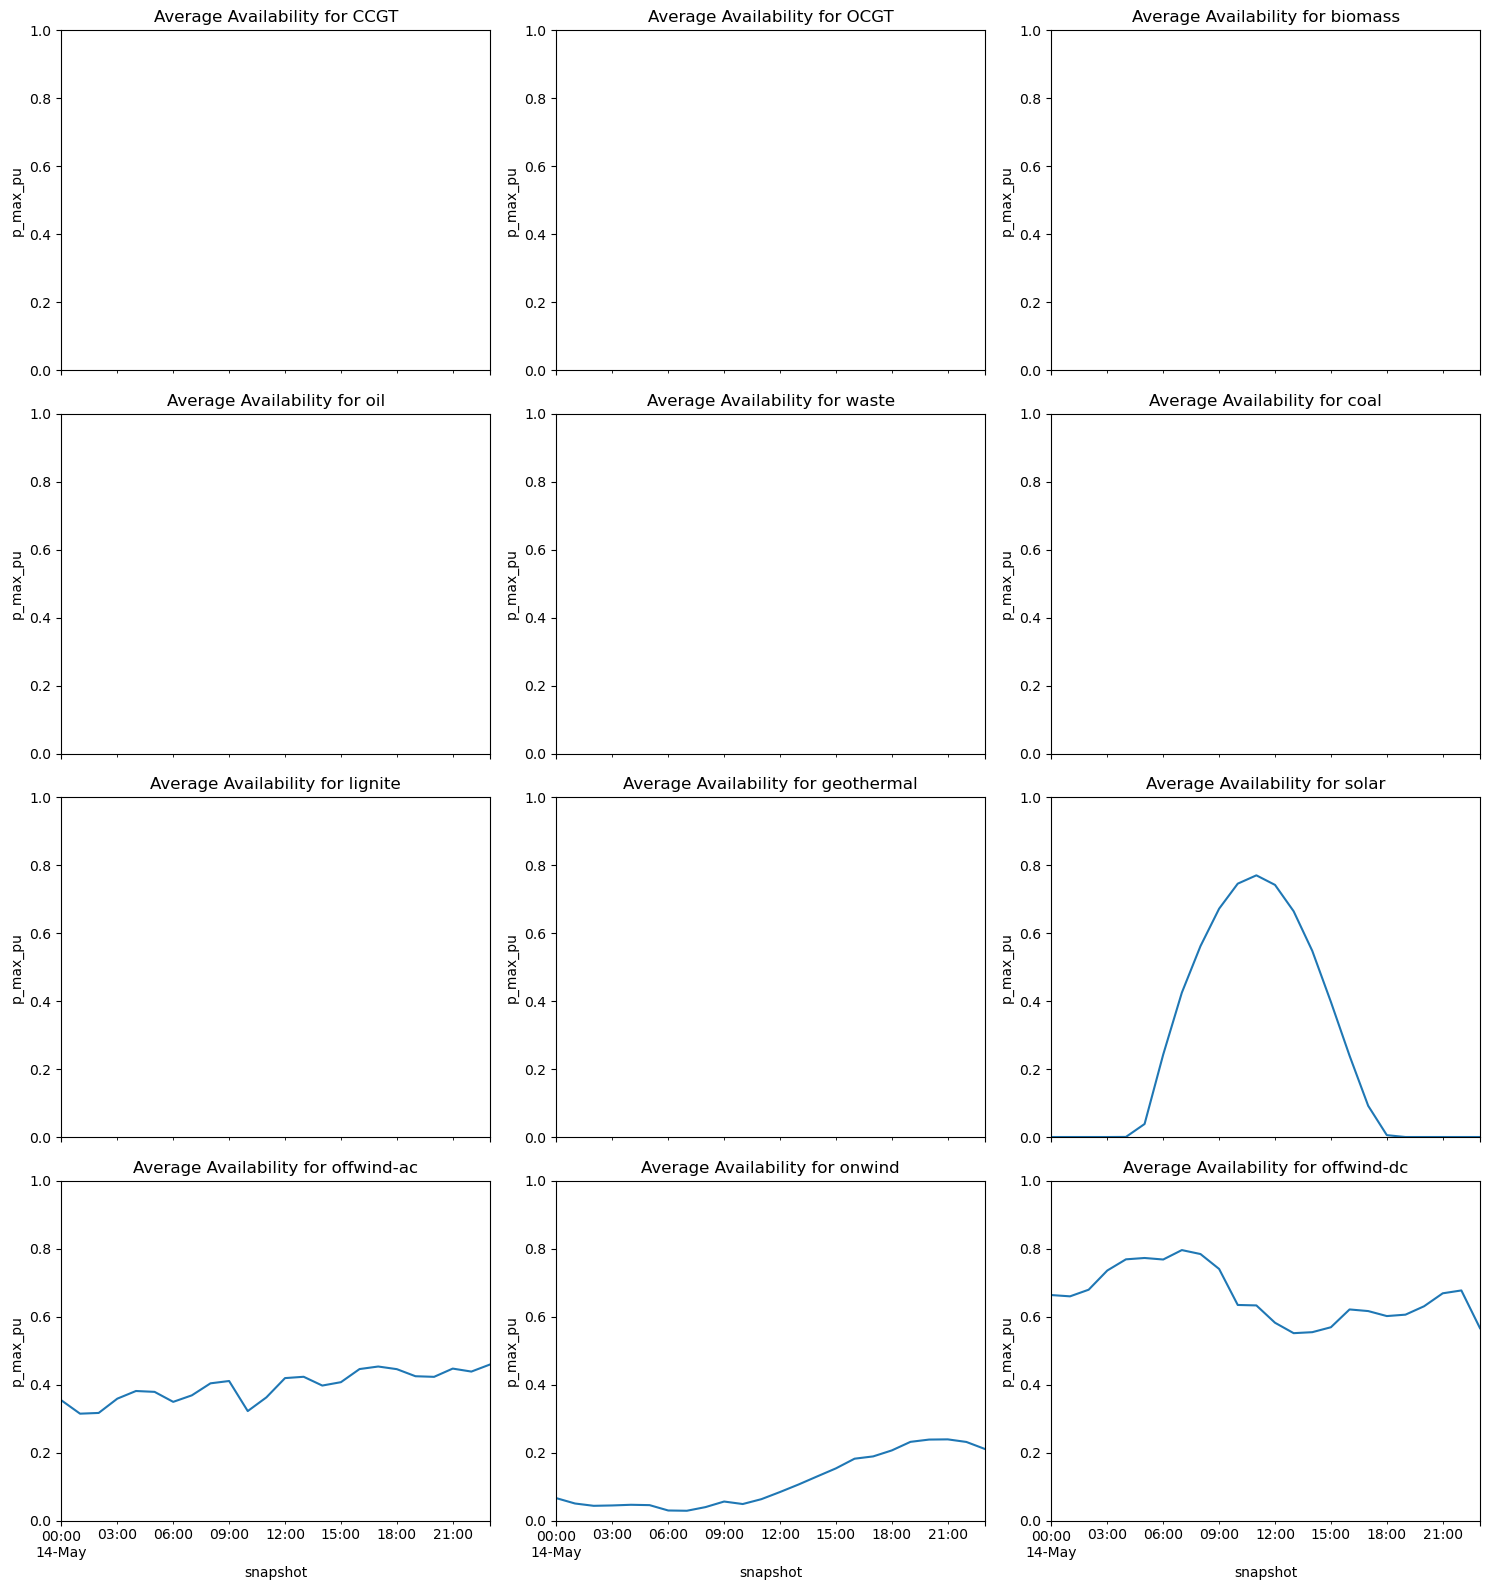

In [68]:
# Get all unique carriers
carriers = n.generators.carrier.unique()

# Create a figure with subplots for each carrier
n_carriers = len(carriers)
n_cols = 3
n_rows = (n_carriers + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4), sharex=True)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, carrier in enumerate(carriers):
    ax = axes[i]
    
    # Find all generators for the current carrier
    gens_for_carrier = n.generators.index[n.generators.carrier == carrier]
    
    # Find the intersection of generators for the carrier and columns in p_max_pu
    common_gens = n.generators_t.p_max_pu.columns.intersection(gens_for_carrier)
    
    # Plot the AVERAGE p_max_pu for these generators
    if not common_gens.empty:
        p_max_pu_carrier = n.generators_t.p_max_pu[common_gens]
        p_max_pu_carrier.mean(axis=1).plot(ax=ax, legend=False)
    
    ax.set_title(f"Average Availability for {carrier}")
    ax.set_ylabel("p_max_pu")
    ax.set_ylim(0, 1)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 4.3. Power Dispatch by Carrier
This stacked area plot shows the total power generated (dispatched) by each major carrier type over time.

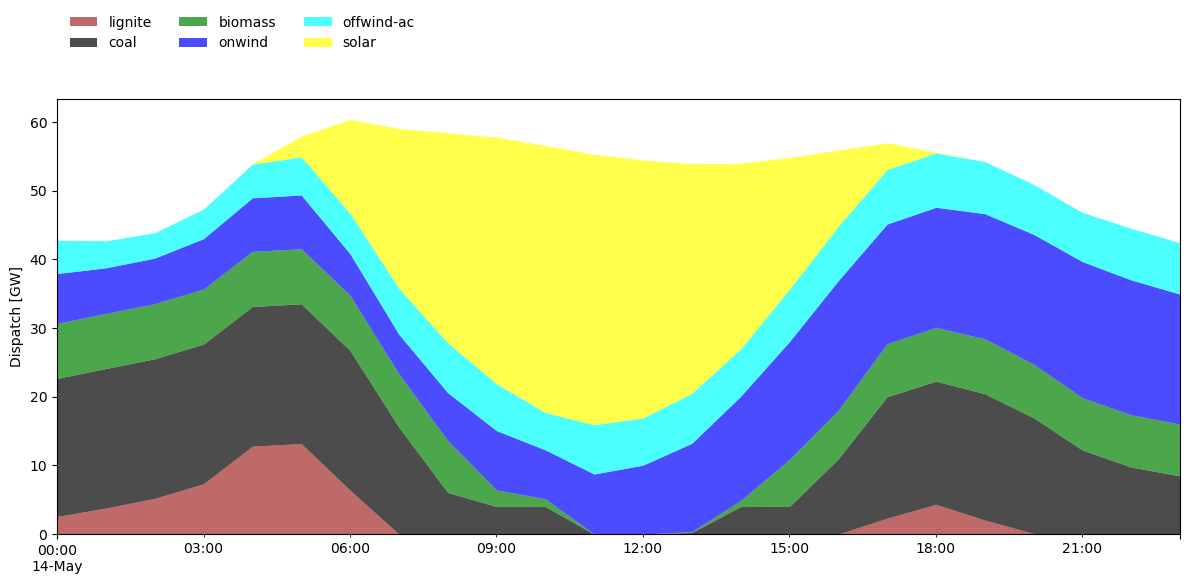

In [69]:
p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
# Drop carriers with very low production for clarity
to_drop = p_by_carrier.max()[p_by_carrier.max() < 1700].index
p_by_carrier.drop(to_drop, axis=1, inplace=True)

# Define colors and order for the dispatch plot
colors = {
    "biomass": "green", "coal": "black", "lignite": "brown",
    "offwind-ac": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "orange", "oil": "gray", "ror": "turquoise", "geothermal": "red",
}
# Reorder columns for a conventional stack
cols = [
    "lignite", "coal", "biomass", "onwind", "offwind-ac", "solar",
]
p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

c = [colors.get(col, "gray") for col in p_by_carrier.columns]
fig, ax = plt.subplots(figsize=(12, 6))
p_by_carrier.div(1e3).plot(kind="area", ax=ax, lw=0, color=c, alpha=0.7)
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, 1.02, 1, 0.2), frameon=False)
ax.set_ylabel("Dispatch [GW]")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

### 4.4. Curtailment Analysis
Curtailment is the reduction in the output of a generator from what it could otherwise produce. Here we calculate and plot it for the 'onwind' carrier as an example.

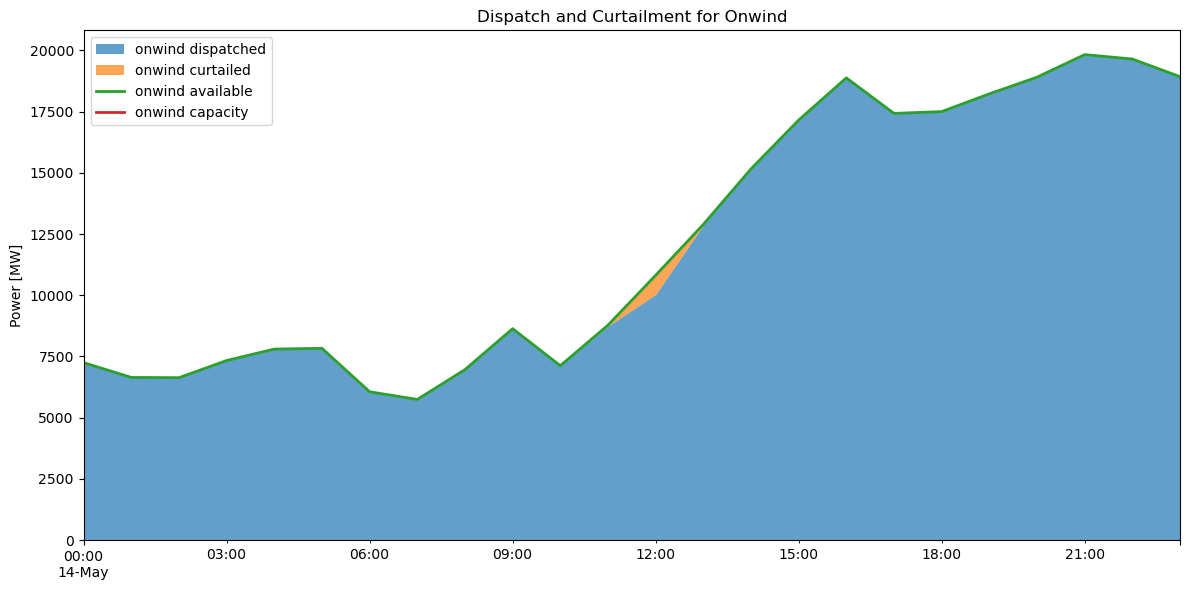

In [70]:
carrier = "onwind"

capacity = n.generators.groupby("carrier").sum().at[carrier, "p_nom"]
p_available = n.generators_t.p_max_pu.multiply(n.generators["p_nom"])
p_available_by_carrier = p_available.T.groupby(n.generators.carrier).sum().T
p_curtailed_by_carrier = p_available_by_carrier - p_by_carrier

p_df = pd.DataFrame(
    {
        carrier + " available": p_available_by_carrier[carrier],
        carrier + " dispatched": p_by_carrier[carrier],
        carrier + " curtailed": p_curtailed_by_carrier[carrier],
    }
)

p_df[carrier + " capacity"] = capacity

# Correct for any minor negative values from floating point inaccuracies
p_df.loc[p_df[f"{carrier} curtailed"] < 0, f"{carrier} curtailed"] = 0

fig, ax = plt.subplots(figsize=(12, 6))
p_df[[carrier + " dispatched", carrier + " curtailed"]].plot(kind="area", ax=ax, lw=0, alpha=0.7)
p_df[[carrier + " available", carrier + " capacity"]].plot(ax=ax, lw=2)

ax.set_xlabel("")
ax.set_ylabel("Power [MW]")
ax.set_title(f"Dispatch and Curtailment for {carrier.title()}")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Grid and Transmission Analysis
This final section focuses on the state of the transmission grid itself.

### 5.1. Line Length Statistics
A statistical summary of the lengths of the transmission lines in the network.

In [71]:
if not n.lines.empty:
    print("\nLine length statistics [km]:")
    if "length" in n.lines.columns:
        display(n.lines["length"].describe().to_frame("value"))
    else:
        print("No 'length' column in n.lines")


Line length statistics [km]:


,value
count,666.000000
mean,25.044439
std,24.795309
min,1.043104
25%,6.739575
50%,15.831136
75%,37.248927
max,206.742555


### Interesting for IFISC Model
- buses: IDs and coordinates,
- lines: `bus0`, `bus1`, `x` (reactance), `r` (resistance), `s_nom` (nominal power), `length`,
- generators: `bus`, `carrier` (type of energy source e.g. solar, gas), `p_nom` (nominal power),
- loads: `bus`, `p_set` (active power setpoint),
- time series: `generators_t.p` (dispatch), `loads_t.p_set` (active power demand), `buses_t.v_ang` (voltage phase angle)

- Reactance
    - electrical property that impedes changes in current and is crucial for calculating AC power flow. It's a primary factor in determining how power is distributed across parallel paths.
- Resistance 
    - electrical resistance of the line. This causes real power losses (dissipated as heat) as electricity flows through it.
- Nominal power
    - maximum rated active power output of the generator in MW (Megawatts). This is its installed capacity.
- Active Power Setpoint
    - static value representing the profile of the load. It's a multiplier that is combined with the time series data to get the actual demand at any given time.
- Dispatch: (result of the simulation) 
    - showing how much power each generator is actually producing at a given time (in MW).
- active power demand (input)
    - time-varying active power demand for each load at each snapshot (in MW)
- Voltage phase angle (result)
    - The voltage phase angle for each bus at each snapshot (in radians)
    - Power naturally flows from a bus with a leading (higher) phase angle to a bus with a lagging (lower) phase angle -> larger phase angle difference results in a larger amount of power being transferred.

In [73]:
#calculated voltage phase angle for every bus in your network at every time snapshot
phase_angles = n.buses_t.v_ang
phase_angles.head()


name,DE0 0,DE0 1,DE0 10,DE0 100,DE0 101,DE0 102,DE0 103,DE0 104,DE0 105,DE0 106,...,DE0 90 battery,DE0 91 battery,DE0 92 battery,DE0 93 battery,DE0 94 battery,DE0 95 battery,DE0 96 battery,DE0 97 battery,DE0 98 battery,DE0 99 battery
snapshot,,,,,,,,,,,,,,,,,,,,,
2025-05-14 00:00:00,0.066050,-0.267219,0.023661,-0.048430,-0.094989,0.191709,-0.124224,0.080647,0.211438,0.152908,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-05-14 01:00:00,0.052678,-0.245637,0.023562,-0.045218,-0.067145,0.175362,-0.116529,0.068371,0.229130,0.141498,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-05-14 02:00:00,0.036112,-0.239721,0.008775,-0.056216,-0.044793,0.179633,-0.119799,0.066687,0.273446,0.148460,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-05-14 03:00:00,0.018843,-0.257744,-0.025643,-0.088200,-0.027071,0.215306,-0.138198,0.080508,0.348139,0.182742,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2025-05-14 04:00:00,0.063080,-0.323916,-0.046989,-0.120634,-0.046839,0.226234,-0.169553,0.086852,0.365772,0.189402,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
generation = n.generators_t.p
generation.head()

name,DE0 0 CCGT,DE0 0 OCGT,DE0 0 biomass,DE0 0 oil,DE0 0 waste,DE0 1 CCGT,DE0 1 OCGT,DE0 1 biomass,DE0 1 oil,DE0 1 waste,...,DE0 96 0 onwind,DE0 97 0 onwind,DE0 98 0 onwind,DE0 99 0 onwind,DE0 105 0 offwind-dc,DE0 110 0 offwind-dc,DE0 132 0 offwind-dc,DE0 140 0 offwind-dc,DE0 358 0 offwind-dc,DE0 379 0 offwind-dc
snapshot,,,,,,,,,,,,,,,,,,,,,
2025-05-14 00:00:00,0.000103,0.000079,86.658268,0.000028,0.000272,0.000083,0.000079,39.255289,0.000028,0.000272,...,10.785871,9.679323,0.506099,37.351014,0.000111,0.000067,0.000098,0.000135,0.000047,0.000067
2025-05-14 01:00:00,0.000104,0.000080,86.658293,0.000028,0.000276,0.000083,0.000080,39.255313,0.000028,0.000276,...,3.282047,7.929651,0.187333,39.678701,0.000109,0.000068,0.000089,0.000141,0.000054,0.000062
2025-05-14 02:00:00,0.000105,0.000080,86.658330,0.000028,0.000282,0.000084,0.000080,39.255350,0.000028,0.000282,...,-0.000000,7.274830,0.183545,40.017971,0.000109,0.000071,0.000092,0.000143,0.000063,0.000061
2025-05-14 03:00:00,0.000107,0.000081,86.658401,0.000028,0.000298,0.000085,0.000081,39.255421,0.000028,0.000298,...,-0.000000,7.203957,0.184052,48.939374,0.000111,0.000084,0.000099,0.000144,0.000080,0.000073
2025-05-14 04:00:00,0.000119,0.000088,86.658609,0.000029,0.000420,0.000097,0.000092,39.255680,0.000029,0.000514,...,-0.000000,6.491630,0.162792,62.583695,0.000111,0.000100,0.000091,0.000146,0.000097,0.000087


In [75]:
demand = n.loads_t.p_set
demand.head()

name,DE0 0,DE0 1,DE0 10,DE0 100,DE0 101,DE0 102,DE0 103,DE0 104,DE0 105,DE0 106,...,DE0 90,DE0 91,DE0 92,DE0 93,DE0 94,DE0 95,DE0 96,DE0 97,DE0 98,DE0 99
snapshot,,,,,,,,,,,,,,,,,,,,,
2025-05-14 00:00:00,289.831467,310.849350,111.864609,282.097824,73.966728,5.340652,74.140434,244.746414,50.563736,524.128044,...,202.955887,135.591370,184.350510,55.434921,184.881195,421.603592,106.520699,25.496117,42.774193,143.943298
2025-05-14 01:00:00,289.238136,310.212990,111.635605,281.520325,73.815300,5.329720,73.988655,244.245377,50.460228,523.055069,...,202.540405,135.313789,183.973114,55.321442,184.502716,420.740501,106.302635,25.443924,42.686623,143.648621
2025-05-14 02:00:00,297.225868,318.779968,114.718582,289.294914,75.853821,5.476913,76.031960,250.990562,51.853760,537.499992,...,208.133850,139.050674,189.053795,56.849220,189.598030,432.359863,109.238335,26.146599,43.865479,147.615685
2025-05-14 03:00:00,320.526619,343.770439,123.711845,311.973930,81.800308,5.906265,81.992416,270.666740,55.918785,579.636818,...,224.450317,149.951431,203.874496,61.305862,204.461395,466.254318,117.801979,28.196335,47.304268,159.187881
2025-05-14 04:00:00,365.281494,391.770821,140.985626,355.534592,93.222023,6.730957,93.440948,308.459717,63.726685,660.571030,...,255.790131,170.889023,232.341324,69.865952,233.010170,531.357033,134.250572,32.133362,53.909325,181.415161
